## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, 'C:\\Users/jnka0003/Git repos/CIBUSmod')

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenarios

In [27]:
# Create session
session = cm.Session(
    name = 'FORMAS', # <--- Make sure that name and data_path match with multi_proc.py
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
)
# cm.ParameterRetriever.data_path_scenarios = os.path.join('scenarios')

# Define scenarios

session.add_scenario(
    name = 'baseline',
    scenario_workbooks = None, 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'cur',
    scenario_workbooks = 'sng_area', 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'steers',
    scenario_workbooks = ['sng_area', 'steers'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'retired cows',
    scenario_workbooks = ['sng_area', 'ret_cows'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'winter lambs',
    scenario_workbooks = ['sng_area', 'wint_lamb'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'all combined',
    scenario_workbooks = ['sng_area', 'steers', 'ret_cows', 'wint_lamb'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)

A scenario with the name 'baseline' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'cur' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'steers' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'retired cows' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'winter lambs' already exists use .update_scenario() or .remove_scenario() instead.


In [26]:
session.remove_scenario('all combined')

This scenario has output data that will also be removed. Proceed? (Y/N) y


## Plot results

(<Axes: >,
 [<Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>])

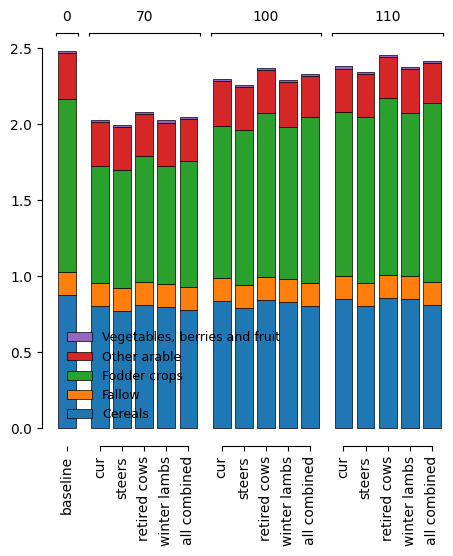

In [8]:
fig, ax = plt.subplots(figsize=(5,5))


In [39]:
sort = plot_data.sum(axis=1).sort_values().index

MultiIndex([(    'baseline',   '0'),
            (         'cur',  '70'),
            ('winter lambs',  '70'),
            ('retired cows',  '70'),
            (      'steers',  '70'),
            ('all combined',  '70'),
            (         'cur', '100'),
            ('winter lambs', '100'),
            ('retired cows', '100'),
            (         'cur', '110'),
            ('winter lambs', '110'),
            ('retired cows', '110'),
            (      'steers', '100'),
            ('all combined', '100'),
            (      'steers', '110'),
            ('all combined', '110')],
           names=['scn', 'year'])

In [67]:
plot_data = session.get_attr('c','fertiliser.mineral_N', 'none')

scn           year
baseline      0       1.392304e+08
cur           70      1.276301e+08
              100     1.356027e+08
              110     1.383342e+08
steers        70      1.246514e+08
              100     1.326131e+08
              110     1.357692e+08
retired cows  70      1.260618e+08
              100     1.338322e+08
              110     1.363627e+08
winter lambs  70      1.275156e+08
              100     1.352721e+08
              110     1.379432e+08
all combined  70      1.235695e+08
              100     1.310173e+08
              110     1.333763e+08
Name: value, dtype: float64

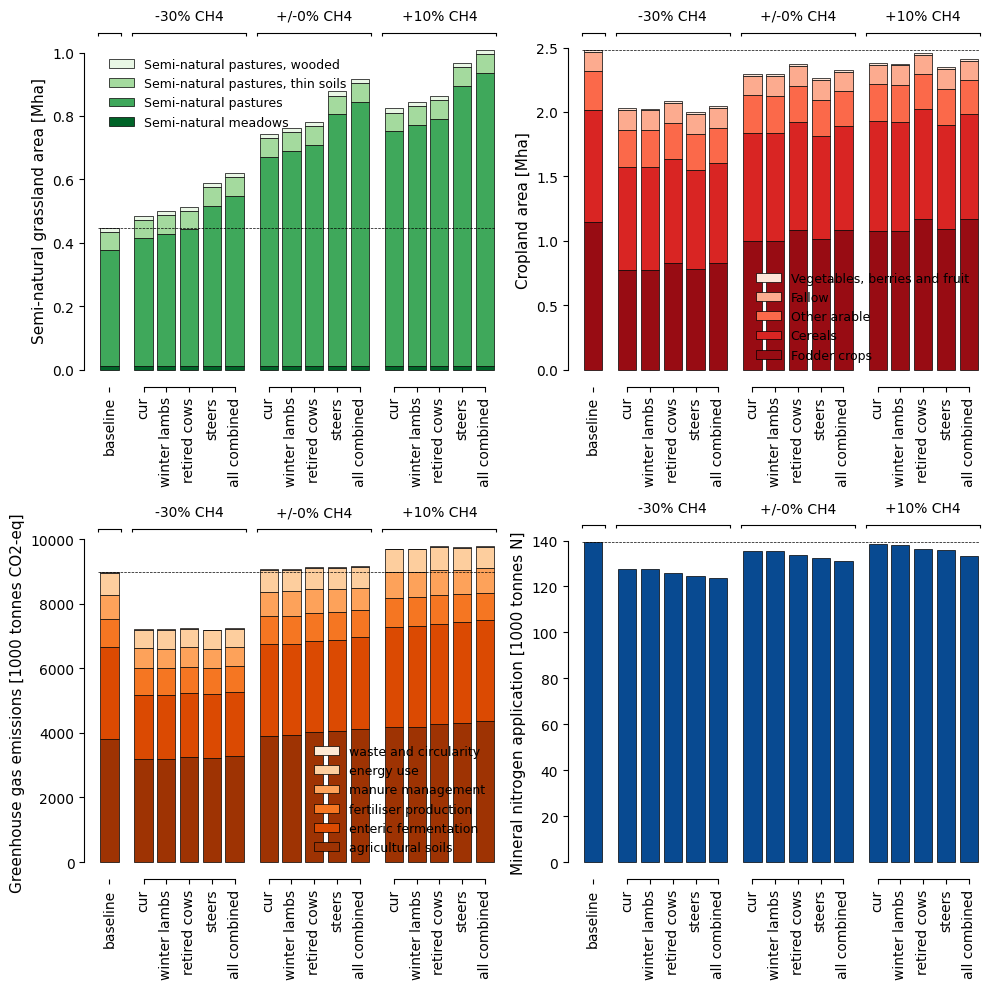

In [88]:
fig, axs = plt.subplots(2,2, figsize=(10,10))

ax=axs[0,0]
plot_data = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .rename(rename_years)
)/1000000
sort = plot_data.sum(axis=1).sort_values().index

cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    group_levels='year',
    sort_xlabels=False,
    sort_groups=False,
    cmap='Greens',
    ylabel='Semi-natural grassland area [Mha]'
)
ax.axhline(plot_data.loc[('baseline','')].sum(), c='black', linewidth=0.5, linestyle='--')

ax = axs[0,1]
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group2']})
    .loc[:,'cropland']
    .rename(rename_years)
)/1000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap='Reds',
    ylabel='Cropland area [Mha]'
)
ax.axhline(plot_data.loc[('baseline','')].sum(), c='black', linewidth=0.5, linestyle='--')


ax = axs[1,0]
plot_data = (
    cm.get_GHG(session, CO2eq = True)
    .T.groupby('process').sum().T
    .rename(rename_years)
)/1000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap='Oranges',
    ylabel='Greenhouse gas emissions [1000 tonnes CO2-eq]'
)
ax.axhline(plot_data.loc[('baseline','')].sum(), c='black', linewidth=0.5, linestyle='--')


ax = axs[1,1]
plot_data = session.get_attr('c','fertiliser.mineral_N', 'none').rename(rename_years)/1000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap='Blues',
    ylabel='Mineral nitrogen application [1000 tonnes N]'
)
ax.axhline(plot_data.loc[('baseline','')].sum(), c='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

In [84]:
cm.get_GHG?

Signature: cm.get_GHG(session, scn='all', years='all', CO2eq=True, interpolate=False)
Docstring:
Parameters
----------
session : Session object
scn : (list of) str, default 'all'
years : (list of) str, default 'all'
CO2eq : Bool, default True
    Translate GHGs to CO2-eq
interpolate : Bool, default False
    Interpolate between defined years
File:      c:\users\jnka0003\git repos\cibusmod\cibusmod\utils\output_data_manip_db.py
Type:      function

In [49]:
# Common style for plots
bar_style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.6
}

bar_style_one = {
    'color' : 'lightgrey',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey'
}

map_style_r = map_style.copy()
map_style_r['cmap'] = map_style_r['cmap'] + '_r'

map_style_div = {
    'cmap' : 'BrBG',
    'edgecolor' : 'grey'
}

# Get final iteration of each scenario
scn_final = [(scn, '100' if '100' in years else '0') for scn, years in session.scenarios('has output').items()]

rename_years = {
    '0' : '',
    '70' : '-30% CH4',
    '100' : '+/-0% CH4',
    '110' : '+10% CH4'
}

### Bar plots: Production and animal heads

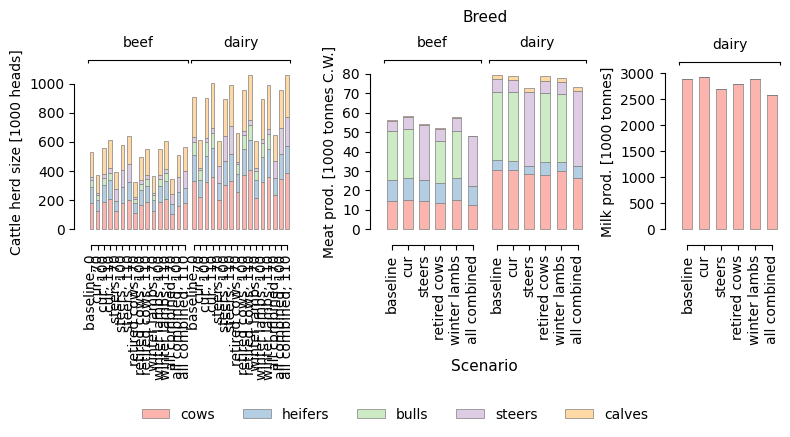

In [11]:
fig, axs = plt.subplots(1,3, figsize=(8,4), width_ratios=(1,1,0.5))

plot_data = (
    session.get_attr('A','heads',['species','animal','breed'])
    .xs('cattle', level='species', axis=1)
    .stack()
    .reindex(['cows','heifers','bulls','steers','calves'], level='animal', axis=1)
)/1000

ax=axs[0]
cm.plot.bar(
    plot_data,
    ax=ax, group_levels=['breed'], sort_xlabels=False, sort_categories=False, **bar_style,
    ylabel='Cattle herd size [1000 heads]', ylabel_fontsize=10
)
ax.get_legend().remove()

plot_data = (
    session.get_attr('A','production',['species','animal','animal_prod', 'breed'])
    .loc[scn_final,:]
    .xs('cattle', level='species', axis=1).droplevel('year')
    .stack()
    .reindex(['cows','heifers','bulls','steers','calves'], level='animal', axis=1)
)/1000000

ax = axs[1]
cm.plot.bar(
    plot_data.xs('meat', level='animal_prod', axis=1),
    ax=ax, group_levels='breed', sort_xlabels=False, sort_categories=False, **bar_style,
    grouptitle='Breed', xlabel='Scenario', ylabel='Meat prod. [1000 tonnes C.W.]', ylabel_fontsize=10
)
ax.get_legend().remove()

ax = axs[2]
cm.plot.bar(
    plot_data.drop('beef', level='breed').xs('milk', level='animal_prod', axis=1).reindex(plot_data.columns.unique('animal'), axis=1),
    ax=ax, group_levels='breed', sort_xlabels=False, sort_categories=False, **bar_style,
    ylabel='Milk prod. [1000 tonnes]', ylabel_fontsize=10
)
ax.get_legend().remove()

fig.legend(*axs[0].get_legend_handles_labels(), loc='upper center', bbox_to_anchor=(0.5,0), ncol=5, frameon=False)
plt.tight_layout()
plt.show()

In [31]:
plot_data = pd.concat([
    session.get_attr('c','area',{'crop':'land_use'}).loc[:,'semi-natural grasslands'].rename('SNG')/1000000,
    cm.get_GHG(session).sum(axis=1).rename('GHG')/1000000000
], axis=1).set_index('SNG', append=True)['GHG'].unstack(['scn','year'])

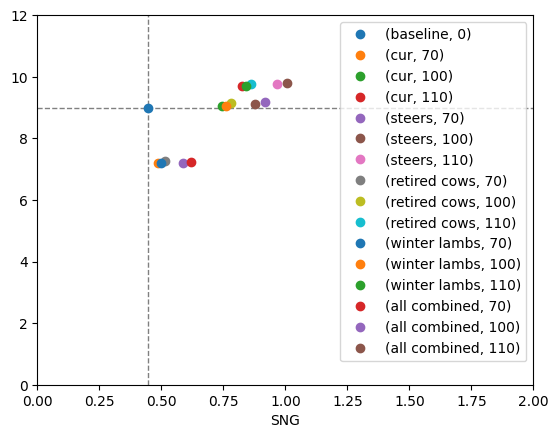

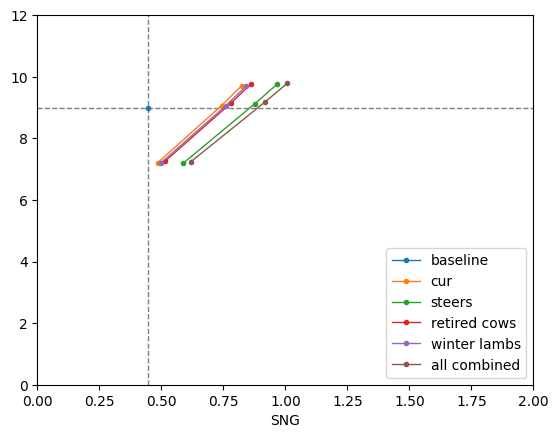

In [32]:
fig,ax = plt.subplots()
ax.axhline(y=plot_data['baseline'].dropna().values, color='grey', linestyle='--', linewidth=1)
ax.axvline(x=plot_data['baseline'].dropna().index.values, color='grey', linestyle='--', linewidth=1)

for col in plot_data.columns:
    plot_data[col].dropna().plot(linestyle='', marker='o')

ax.set_xlim([0,2])
ax.set_ylim([0,12])

ax.legend()
plt.show()

# ------------------------------------------ #

fig,ax = plt.subplots()
ax.axhline(y=plot_data['baseline'].dropna().values, color='grey', linestyle='--', linewidth=1)
ax.axvline(x=plot_data['baseline'].dropna().index.values, color='grey', linestyle='--', linewidth=1)

for scn in plot_data.columns.unique('scn'):
    plot_data.droplevel('year',axis=1).T.groupby('scn').sum().T.replace({0:np.nan}).loc[:,scn].dropna().plot(marker='.', linestyle='-', linewidth=1)

ax.set_xlim([0,2])
ax.set_ylim([0,12])

ax.legend()
plt.show()

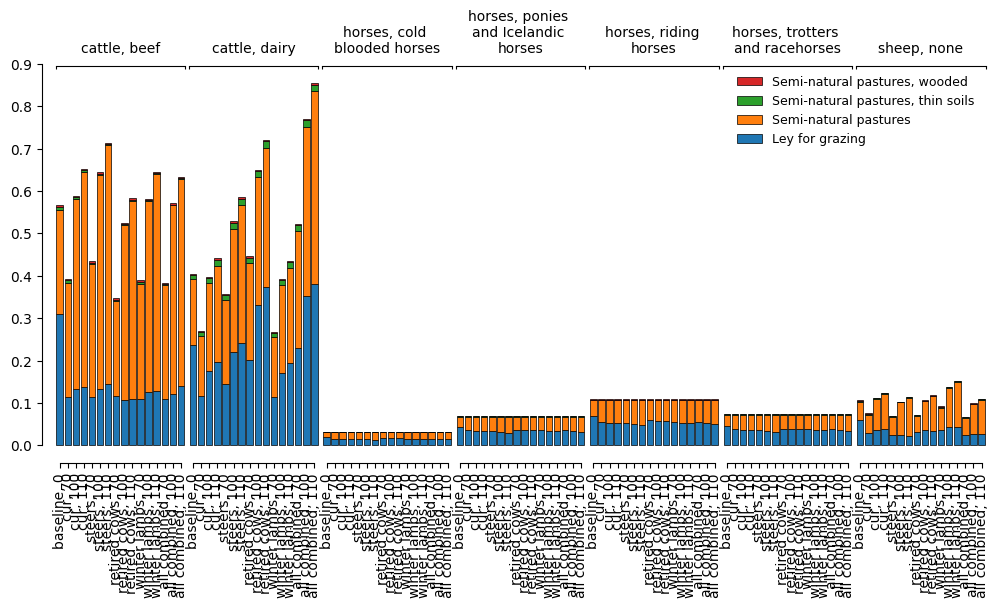

In [14]:
plot_data = (
    session.get_attr('c','production_per_use',['crop','demand'])
    .loc[:,['Ley for grazing', 'Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']]
)/1000000000
plot_data.columns = pd.MultiIndex.from_tuples(
    [(cr,) + tuple(an.replace('feed (','').replace(')','').split(', ')) for cr, an in plot_data.columns],
    names = ['crop', 'species', 'breed', 'sub_system']
)
plot_data = (
    plot_data.T.groupby(['species','breed','crop']).sum().T
    .stack(['species','breed'])
)
# for sp,br,ss in plot_data.index.droplevel(['scn','year']).unique():
fig,ax = plt.subplots(figsize=(12,5))
d = plot_data#.xs((sp,br,ss), level=('species','breed','sub_system')).dropna(axis=1)
cm.plot.bar(
    d,
    ax=ax,
    group_levels=['species','breed'],
    sort_groups=False,
    sort_xlabels=False,
    sort_categories=False
)
# ax.axhline(d.loc['baseline'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
plt.show()

In [20]:
d=session.get_attr('ge','x_an',['species','sub_system']).loc[:,'sheep']
d.div(d.sum(axis=1), axis=0)*100

sub_system         autumn lamb  other sheep  spring lamb  winter lamb
scn          year                                                    
baseline     0       24.800000         42.9         18.0    14.300000
cur          70      33.000000         42.9          9.8    14.300000
             100     33.000000         42.9          9.8    14.300000
             110     33.000000         42.9          9.8    14.300000
steers       70      33.000000         42.9          9.8    14.300000
             100     33.000000         42.9          9.8    14.300000
             110     33.000000         42.9          9.8    14.300000
retired cows 70      33.000000         42.9          9.8    14.300000
             100     33.000000         42.9          9.8    14.300000
             110     33.000000         42.9          9.8    14.300000
winter lambs 70       0.025391         42.9          0.0    57.074609
             100      0.017100         42.9          0.0    57.082900
             110      0.015435         42.9          0.0    57.084565
all combined 70      33.000000         42.9          9.8    14.300000
             100     33.000000         42.9          9.8    14.300000
             110     33.000000         42.9          9.8    14.300000

<Axes: xlabel='sub_system'>

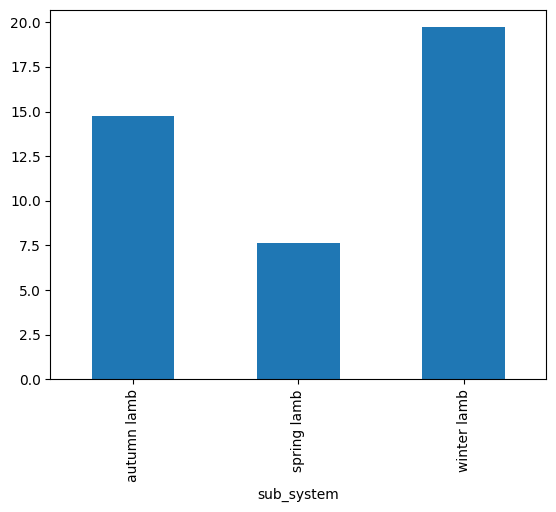

In [43]:
g=session.get_attr('a','feed.crop_product_demand', ['crop_prod','species','sub_system']).loc[('baseline','0'),('grazing','sheep')]
g
h=session.get_attr('a','prod', ['animal_prod','species','sub_system']).loc[('baseline','0'),('meat','sheep')]
# h=session.get_attr('a','prod',['species','animal_prod']).loc[:,('sheep','meat')].xs('100', level='year')
h


g.div(h,axis=0).drop('other sheep').plot(kind='bar', stacked=True)

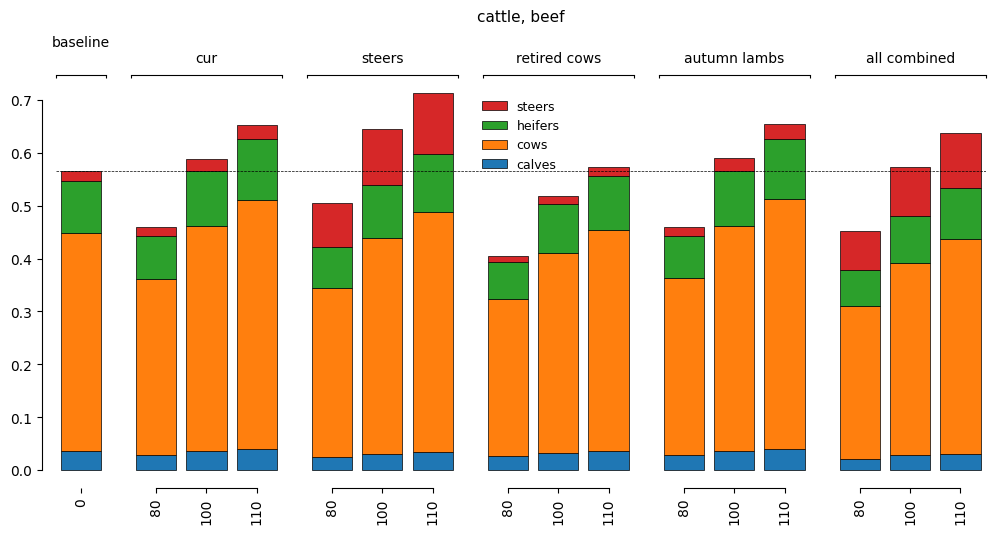

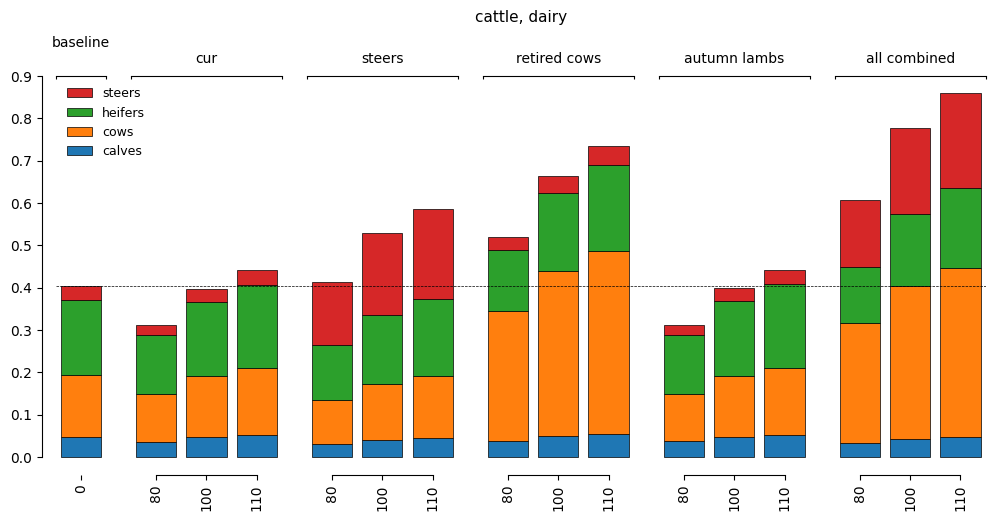

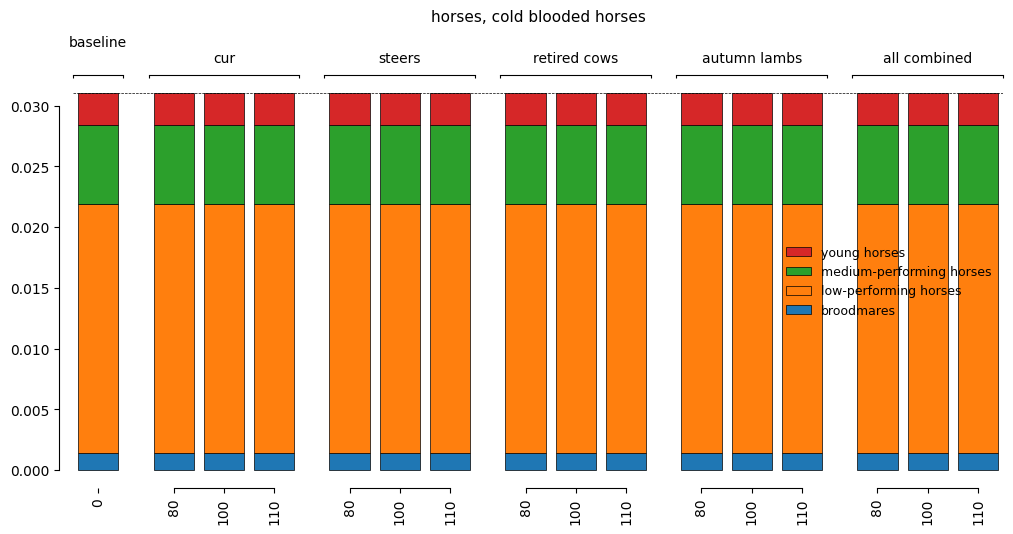

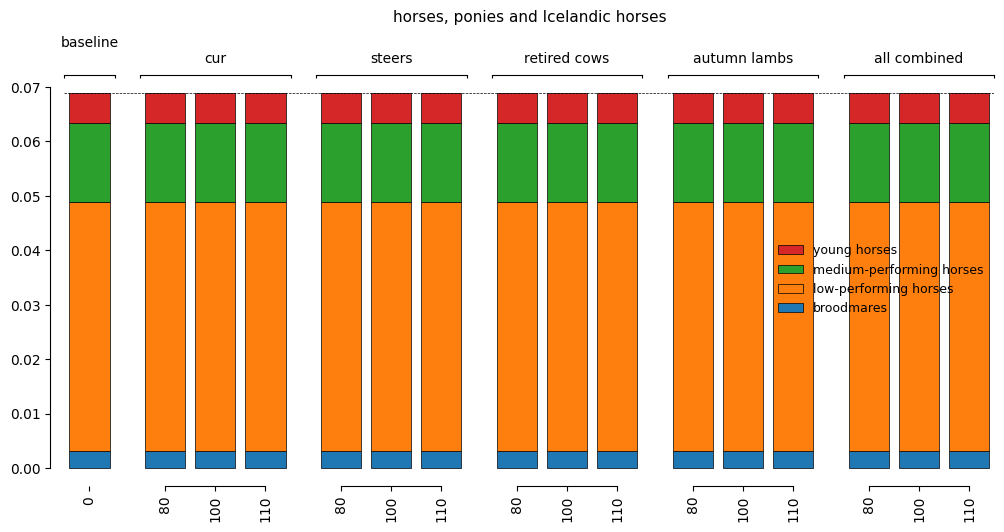

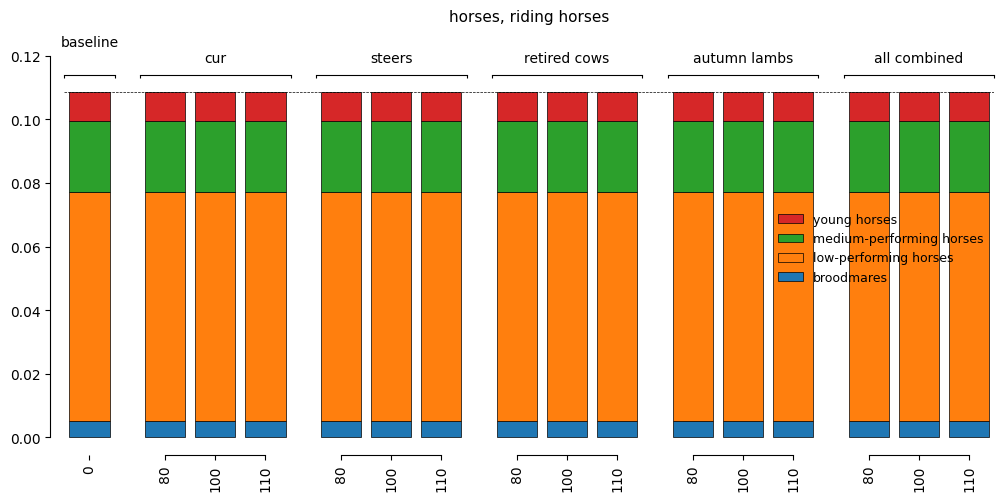

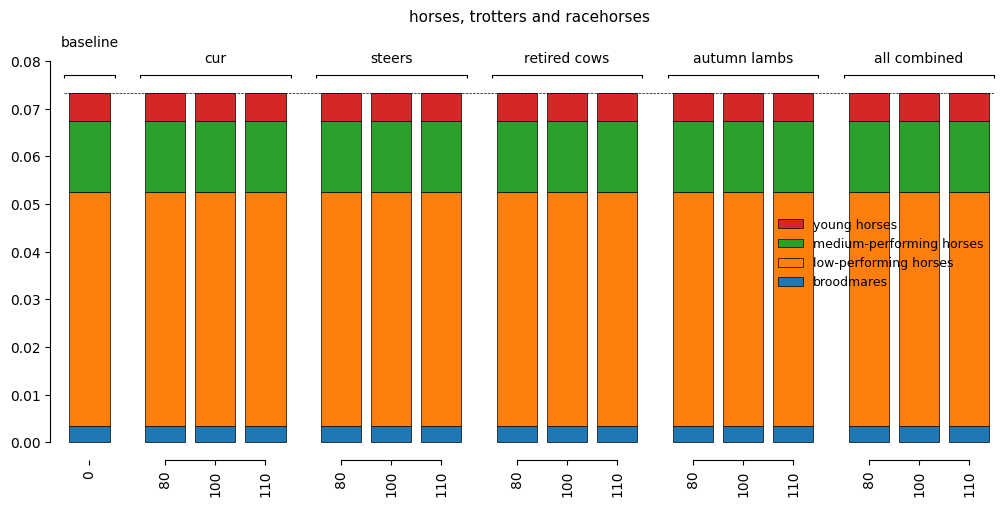

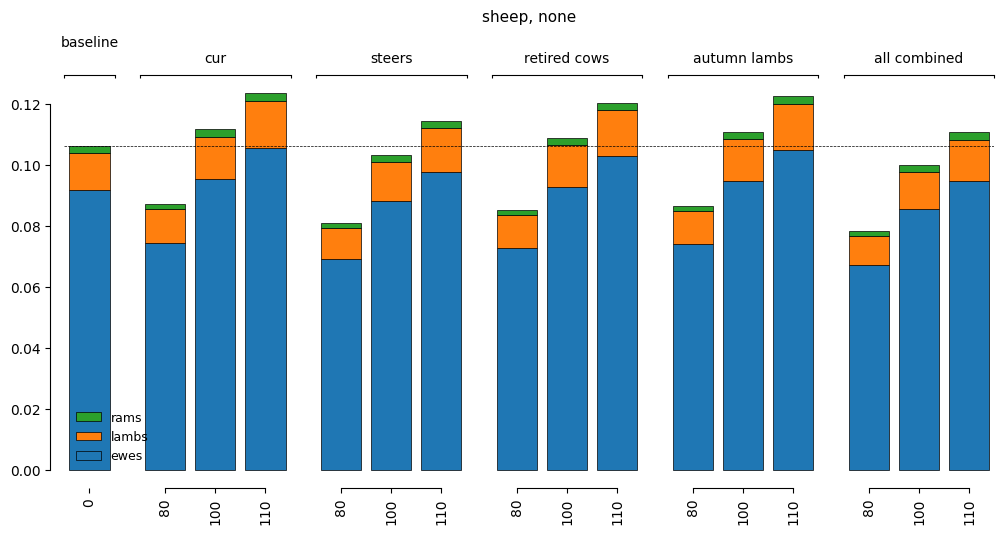

In [9]:
plot_data = (
    session.get_attr('a','feed.crop_prod',['origin','crop_prod','species','breed','animal'])
    .loc[:,'domestic']
    .loc[:,'grazing']
    .stack(['species','breed'])
)/1000000000
for sp,br in plot_data.index.droplevel(['scn','year']).unique():
    fig,ax = plt.subplots(figsize=(12,5))
    d = plot_data.xs((sp,br), level=('species','breed')).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['scn'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=f"{sp}, {br}"
    )
    ax.axhline(d.loc['baseline'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    plt.show()

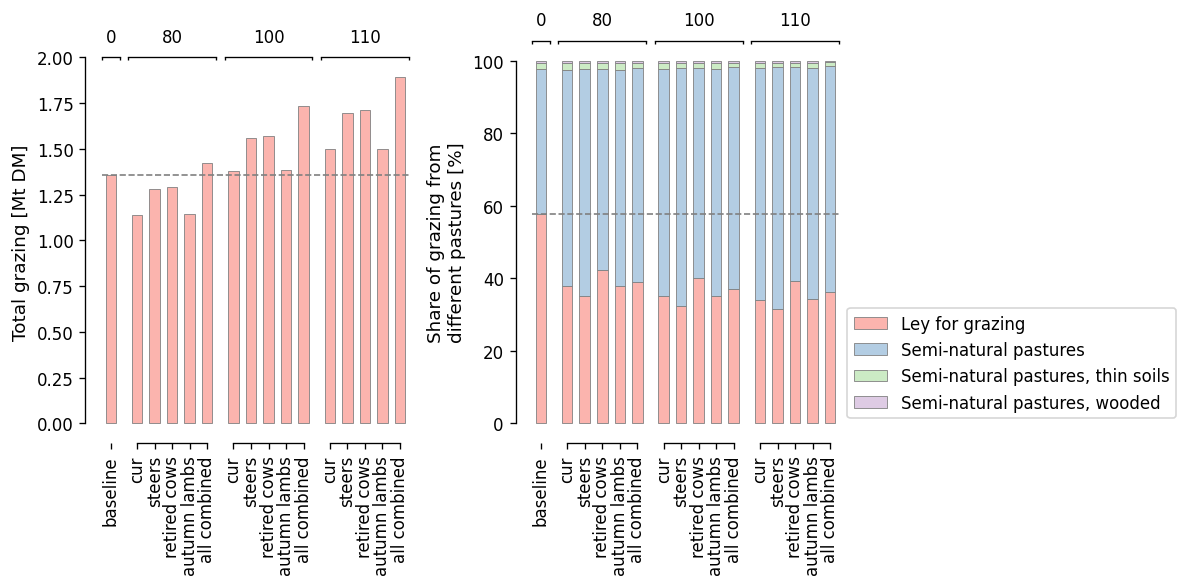

scn           year
baseline      0       42.391793
cur           80      62.149422
              100     64.896491
              110     65.922416
steers        80      65.031785
              100     67.558326
              110     68.506476
retired cows  80      57.776061
              100     59.967874
              110     60.758388
autumn lambs  80      62.033013
              100     64.772162
              110     65.795058
all combined  80      60.935376
              100     62.967922
              110     63.781726
Name: Ley for grazing, dtype: float64

In [37]:
grazing = session.get_attr('C', 'production', ['crop_prod','crop']).loc[:,'grazing']
grazing = grazing.loc[:,grazing.sum()!=0]

plot_data1 = (
    grazing
    # .loc[SCN_NAME]
    # .rename(scn_name_map)
    /1000000000
)

plot_data2 = plot_data1.apply(lambda x: x/x.sum()*100, axis=1)

fig,axs = plt.subplots(1,2, figsize=(10,5), dpi=120)
ax=axs[0]
cm.plot.bar(plot_data1.sum(axis=1), group_levels='year', **bar_style, ax=ax, sort_xlabels=False, sort_groups=False)
ax.axhline(y=plot_data1.sum(axis=1).loc['baseline'].iloc[0], linestyle='--', linewidth=1, color='grey')
ax.set_ylabel('Total grazing [Mt DM]')
# ax.set_xlabel('')

ax = axs[1]
cm.plot.bar(plot_data2, group_levels='year', **bar_style, ax=ax, sort_xlabels=False, sort_groups=False, sort_categories=False)
ax.axhline(y=plot_data2.loc['baseline','Ley for grazing'].iloc[0], linestyle='--', linewidth=1, color='grey')
ax.legend(loc='lower left', ncol=1, bbox_to_anchor=(1, 0), fontsize=10)
ax.set_ylabel('Share of grazing from\ndifferent pastures [%]')
# ax.set_xlabel('')

plt.tight_layout()
plt.show()

100-plot_data2.loc[:,'Ley for grazing']

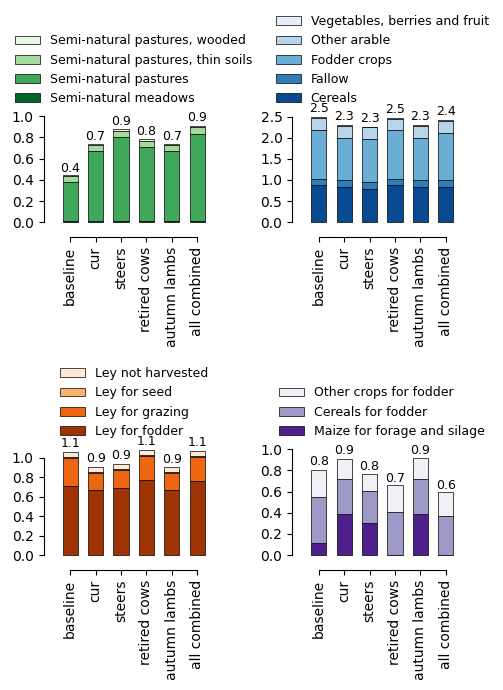

In [8]:
fig, axs = plt.subplots(2,2, figsize=(5,7), width_ratios=(1,1))
axs = axs.flatten()

ax = axs[0]
plot_data = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[scn_final,:]
    .droplevel('year')
    .loc[:,'semi-natural grasslands']
)/1000000
cm.plot.bar(plot_data, ax=ax, bar_width=0.6, sort_xlabels=False, cmap='Greens')
for x,y in enumerate(plot_data.sum(axis=1)):
    ax.text(x=x+0.5, y=y*1.05, s=str(round(y,1)), ha='center', size=9)

ax=axs[1]
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group2']})
    .loc[scn_final,:]
    .droplevel('year')
    .loc[:,'cropland']
)/1000000
cm.plot.bar(plot_data, ax=ax, bar_width=0.6, sort_xlabels=False, cmap='Blues')
for x,y in enumerate(plot_data.sum(axis=1)):
    ax.text(x=x+0.5, y=y*1.05, s=str(round(y,1)), ha='center', size=9)

ax=axs[2]
plot_data = (
    session.get_attr('c','area',{'crop':['crop_group',None]})
    .loc[scn_final,:]
    .droplevel('year')
    .loc[:,'Ley']
)/1000000
cm.plot.bar(plot_data, ax=ax, bar_width=0.6, sort_xlabels=False, cmap='Oranges')
for x,y in enumerate(plot_data.sum(axis=1)):
    ax.text(x=x+0.5, y=y*1.05, s=str(round(y,1)), ha='center', size=9)

ax=axs[3]
plot_data = (
    session.get_attr('c','area',{'crop':[None]})
    .loc[scn_final,:]
    .droplevel('year')
    .loc[:,['Maize for forage and silage', 'Cereals for fodder', 'Other crops for fodder']]
)/100000
cm.plot.bar(plot_data, ax=ax, bar_width=0.6, sort_xlabels=False, cmap='Purples')
for x,y in enumerate(plot_data.sum(axis=1)):
    ax.text(x=x+0.5, y=y*1.05, s=str(round(y,1)), ha='center', size=9)

for ax in axs.flatten():
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,1), frameon=False, ncol=1, fontsize=9, reverse=True)

plt.tight_layout()
plt.show()

### Bar plots: GHG and land use

### Maps: Land use and cattle numbers

TypeError: 'Axes' object is not subscriptable

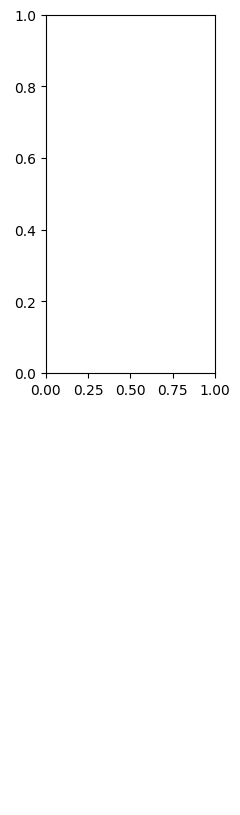

In [85]:
plot_data = (
    session.get_attr('c','area',{'crop':'land_use', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('baseline','0')],axis=1))
    .drop(('baseline','0'))
    .droplevel('year')
)/1000


n_scn = len(plot_data)
lims = plot_data.T.abs().groupby('land_use').max().max(axis=1)

# fig,axs = plot.subplots(plot_data.T.drop('greenhouse'),
#                         size=(2.5,4), columns='scn', index='land_use', title_fontsize=11,
#                         plot_fn=plot.map_from_series,
#                         cmap_zero_midpoint=False, **map_style_div, vmax=8, vmin=-8)
# for ax in axs.flatten():
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

fig = plt.figure(layout='constrained', figsize=(2.2*n_scn, 8))
subfigs = fig.subfigures(2, 1, wspace=0.07)

# Semi-natural grasslands
axs1 = subfigs[0].subplots(1,n_scn)
for n, scn in enumerate(plot_data.index):
    ax = axs1[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'semi-natural grasslands'],
        ax = ax,
        vmin=-lims.loc['semi-natural grasslands'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['semi-natural grasslands'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[0].suptitle('Change in semi-natural grassland area [1000 ha]', size=11)

# Cropland
axs2 = subfigs[1].subplots(1,n_scn)
# fig, axs = plt.subplots(1,n_scn, figsize=(2.2*n_scn,4))
for n, scn in enumerate(plot_data.index):
    ax = axs2[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'cropland'],
        ax = ax,
        vmin=-lims.loc['cropland'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['cropland'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[1].suptitle('Change in cropland area [1000 ha]', size=11)
# fig.tight_layout()
plt.show()

In [86]:
n_scn = len(scenarios)-1
fig, axs = plt.subplots(1,n_scn, figsize=(4*n_scn,7))
n=0
for scn in list(scenarios.keys())[1:]:
    plot_data = (
        output.loc[(scn,year),'ani'].heads.xs(('cattle','dairy'), axis=1).sum(axis=1) -
        output.loc[('baseline',year),'ani'].heads.xs(('cattle','dairy'), axis=1).sum(axis=1)
    )/1000
    ax = axs[n]
    plot.map_from_series(
        plot_data,
        ax = ax,
        vmin=-5,
        vmax=5,
        **map_style_div
    )
    ax.set_title(scn)
    n += 1
plt.suptitle('Change in total number of cattle in dairy herds [1000 heads]', size=14)
plt.show()

fig, axs = plt.subplots(1,n_scn, figsize=(4*n_scn,7))
n=0
for scn in list(scenarios.keys())[1:]:
    plot_data = (
        output.loc[(scn,year),'ani'].heads.xs(('cattle','beef'), axis=1).sum(axis=1) -
        output.loc[('baseline',year),'ani'].heads.xs(('cattle','beef'), axis=1).sum(axis=1)
    )/1000
    ax = axs[n]
    plot.map_from_series(
        plot_data,
        ax = ax,
        vmin=-5,
        vmax=5,
        **map_style_div
    )
    ax.set_title(scn)
    n += 1
plt.suptitle('Change in total number of cattle in beef herds [1000 heads]', size=14)
plt.show()



NameError: name 'scenarios' is not defined

## Run scenarios (multi proc.)

In [4]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run

In [28]:
# Create list of scenarios to run
runs = [(s,y) for s,y in session.iterate('no output')]

In [29]:
runs

[('all combined', '70'), ('all combined', '100'), ('all combined', '110')]

In [30]:
%%time
# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
            
session.cache.clear()                  

all combined, 100 finished successfully in 3min 3s
all combined, 110 finished successfully in 3min 6s
all combined, 70 finished successfully in 3min 8s
CPU times: total: 0 ns
Wall time: 3min 37s


## Run scenarios here

In [18]:
import sys
import os
import time
from contextlib import redirect_stdout, redirect_stderr
import numpy as np
import scipy
import cvxpy
import matplotlib.pyplot as plt
sys.path.insert(0, 'C:/Users/jnka0003/Git repos/CIBUSmod')
import CIBUSmod as cm
from CIBUSmod.utils.helpers import check_constraints

In [19]:
# Create session (Make sure that name and data_path match the notebook!)
session = cm.Session(
    name = 'FORMAS',
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
    timeout = 60 # Increase timeout to avoid failing to write if multiple processes try to write at the same time
)

In [20]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate by-product management
byprod_mgmt = cm.ByProductMgmt(
    demand = demand,
    herds = herds,
    par = cm.ParameterRetriever('ByProductMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

In [21]:
def _max_sng_obj(geodist):
    geodist.define_cvx_problem()

    # Get x variable
    x = geodist.problem.variables()[0]

    # Create objective
    rel = cm.ParameterRetriever.get_rel('crop','land_use')
    P = np.concatenate([
        np.zeros(len(geodist.x_idx_short['ani'])),
        np.array([1 if rel[cr] == 'semi-natural grasslands' else 0 for cr,_,_ in geodist.x_idx_short['crp']])
    ])
    obj = cvxpy.Maximize(
        cvxpy.sum(cvxpy.multiply(P, x))
    )
    
    # Create problem
    geodist.problem = cvxpy.Problem(
        objective = obj,
        constraints = geodist.problem.constraints
    )

In [22]:
def _make_ani_cons(geodist, name, M, b, rel):
    
    from CIBUSmod.optimisation.geo_dist import IndexedMatrix
    
    # Create A matrix
    M = scipy.sparse.csc_matrix(M)
    Z = scipy.sparse.csc_matrix((M.shape[0],len(geodist.x_idx_short['crp']))) # Zero matrix
    A = scipy.sparse.hstack([M,Z], format='csc')
    A = IndexedMatrix(
        matrix=A,
        row_idx=pd.Index([name]),
        col_idx={k:v.copy() for k,v in geodist.x_idx_short.items()}
    )
    
    # Append constraint
    geodist.constraints.update({f'{name}: A @ x {rel} b' : {
        'left' : lambda x,A: A.M @ x,
        'right' : lambda A: b,
        'rel' : rel,
        'pars' : {'A':A}
    }})

    return None

In [23]:
def _get_herds_par(herds, attr):
    
    res = pd.concat([
        pd.concat({h.species: 
            pd.concat({h.breed:
                pd.concat({h.prod_system:
                    pd.concat({h.sub_system:
                        h.data_attr.get(attr)
                    }, names=['sub_system'])
                }, names=['prod_system'])
            }, names=['breed'])
        }, names=['species'])
    for h in herds])

    return res

In [24]:
def _make_CH4_cons(geodist, feed_mgmt, baseline_CH4, factor):
    
    feed_mgmt.calculate2()
    
    # Get CH4 emissions per defining animal
    CH4 = _get_herds_par(herds, 'enteric_methane').sum(axis=1).reindex(geodist.x_idx_short['ani'])
    
    # Assert that indexes match
    assert (CH4.index == geodist.x_idx_short['ani']).all()
    
    _make_ani_cons(geodist, name='CH4', M=CH4, b=baseline_CH4 * factor, rel='<=')

    return None

In [25]:
def _make_milkmeat_cons(geodist, baseline_milkmeat):

    # Get milk and meat prod. per defining animal
    meat = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    milk = _get_herds_par(herds, 'production').xs('milk', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    milkmeat = (milk - meat*baseline_milkmeat)
    _make_ani_cons(geodist, name='milk/meat', M=milkmeat, b=0, rel='==')

    return None

In [26]:
def _make_beeflamb_cons(geodist, baseline_beeflamb):

    # Get beef and lamb prod. per defining animal
    beef = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    lamb = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('sheep', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    beeflamb = (beef - lamb*baseline_beeflamb)
    _make_ani_cons(geodist, name='beef/lamb', M=beeflamb, b=0, rel='==')

    return None

In [27]:
# Create list of scenarios to run
runs = [(s,y) for s,y in session.iterate('all')]

In [ ]:
for scn, year in runs:
    
    tic = time.time()
    scn_str = f'Scenario: {scn}, {year}'
    print(f'\n{"-"*len(scn_str)}\n{scn_str}\n{"-"*len(scn_str)}\n')
    
    # Update all parameter values
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year = year
    )
    
    # Get region attributes
    regions.calculate(verbose=True)
    
    # Calculate food demand
    demand.calculate(verbose=True)
    
    # Calculate crops
    crops.calculate(verbose=True)
    
    # Calculate herds
    for h in herds:
        h.calculate(verbose=True)
    
    # Calculate feed
    feed_mgmt.calculate(verbose=True)
    
    if scn != 'baseline':
        while True:
            try:
                # Get baseline crop areas, animal numbers and land use
                baseline_ani = session.get_attr('geo','x_animals', scn='baseline').iloc[0]
                baseline_crp = session.get_attr('geo','x_crops', scn='baseline').iloc[0]
                baseline_lu = session.get_attr('c','area',{'region':None, 'crop':'land_use'}, scn='baseline').iloc[0].unstack()
                # Get baseline CH4 emissions
                baseline_CH4 = session.get_attr(
                    'A', 'enteric_methane',
                    'none',
                    scn='baseline'
                ).iloc[0]
                # Get baseline milk/meat
                prod = session.get_attr('A', 'prod', ['species', 'animal_prod'], scn='baseline').iloc[0]
                baseline_milkmeat = prod[('cattle','milk')] / prod[('cattle','meat')]
                # Get baseline beef/lamb
                prod = session.get_attr('A', 'prod', ['species','animal_prod'], scn='baseline').iloc[0]
                baseline_beeflamb = prod[('cattle','meat')] / prod[('sheep','meat')]
            except:
                time.sleep(10)
            else:
                break
    
    # Distribute animals and crops
    # Make optimisation problem
    if scn == 'baseline':
        geodist.make(
            use_cons=[1,2,3,4,5,6,7],
            scale_power=0.4,
            verbose=True
        )
        # Solve optimisation problem
        geodist.solve(verbose=True)
    else:
        # Drop demand for cattle, sheep and horses
        demand.data_attr.update(
            'animal_prod_demand',
            demand.data_attr.get('animal_prod_demand')
            .loc[(slice(None),['pigs','poultry'],slice(None))]
        )
    
        # Set maximum cropland and greenhouse area to baseline levels
        regions.data_attr.get('max_land_use').update(baseline_lu.loc[:,['cropland','greenhouse']])
    
        # Baseline Semi-natural grassland areas
        C8_SNG_P = baseline_crp.copy()\
        .loc[['Semi-natural pastures']]
        C8_SNG_PWT = baseline_crp.copy()\
        .loc[['Semi-natural pastures, wooded','Semi-natural pastures, thin soils']]
        C8_SNG_M = baseline_crp.copy()\
        .loc[['Semi-natural meadows']]
        C8_FAL = baseline_crp.copy()\
        .loc[['Fallow', 'Ley not harvested']]# * 0.8
        C8_ani = baseline_ani.copy()
    
        geodist.make(
            use_cons=[1,2,3,4,5,6,7,8],
            scale_power=0.4,
            C8_crp = [ C8_SNG_P,   C8_SNG_PWT,   C8_SNG_M,   C8_FAL,   None                    ],
            C8_ani = [ None,       None,         None,       None,     C8_ani.loc[['horses']]  ],
            C8_rel = [ '>=',       '==',         '==',       '>=',     '=='                    ],
            verbose=True
        )
        
        # Add constraint on CH4 emissions and milk/meat
        CH4_factor = float(year)/100
        _make_CH4_cons(geodist, feed_mgmt, baseline_CH4, CH4_factor)
        _make_milkmeat_cons(geodist, baseline_milkmeat)
        _make_beeflamb_cons(geodist, baseline_beeflamb)
    
        # First we solve with the obejctive of maximising semi-natural grassland area
        _max_sng_obj(geodist)
        geodist.solve(apply_solution=False, verbose=True)
    
        # Get semi-natural grassland areas from first solution and add constraint on total
        # semi-natural grassland area for second optimization round
        sng_areas = geodist.x['crp'].loc[['Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']]
        geodist.make_C9(C9_crp = sng_areas * 0.99, C9_rel = '>=') # Introduce a fair bit of slack to avoid unfeasible model
        geodist.make_C7()
    
        # Drop semi-natural grasslands from objective
        cm.helpers.drop_from_objective(geodist, 'crp', 'Semi-natural pastures')
        cm.helpers.drop_from_objective(geodist, 'crp', 'Semi-natural pastures, thin soils')
        cm.helpers.drop_from_objective(geodist, 'crp', 'Semi-natural pastures, wooded')
    
        # Solve optimisation problem again, this time minimising deviation from current
        # crop areas and animal numbers
        geodist.define_cvx_problem()
        geodist.solve(verbose=True)
    
    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=True)
    
    # Balance by-product demand and suply
    byprod_mgmt.calculate(verbose=True)
    
    # Calculate manure
    manure_mgmt.calculate(verbose=True)
    
    # Calculate harvest of crop residues
    crop_residue_mgmt.calculate(verbose=True)
    
    # Calculate treatment of wastes and other feedstocks
    waste.calculate(verbose=True)
    
    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=True)
    
    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=True)
    
    # Calculate inputs supply chain emissions
    inputs.calculate(verbose=True)
    
    # Store results (try again if first atempt fails)
    try:
        session.store(
            scn, year,
            demand, regions, crops, herds, waste, geodist
        )
    except:
        session.store(
            scn, year,
            demand, regions, crops, herds, waste, geodist
        )

    t = time.time() - tic
    m = int(t/60)
    s = int(round(t - m*60))
    print(f'{scn}, {year} finished successfully in {m}min {s}s')

    check_constraints(geodist)
    plt.show()